In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline

### Loading the Dataset - 

In this classification task with decision trees, we will use a car dataset that is avilable at OpenML to predict the car acceptability given the information about the car. We will load it with Sklearn fetch_openml function.

The version of the data we are fetching is 2. In the version 1 of the dataset, the target class had 4 classes (unacc, acc, good, vgood) but in the second version, the majority class is Positive(P) whereas the rest are Negative(P). If you want to see version 1, you can change version parameter in a cell below.

Here are the informations about the features:

* buying: The buying price of the car(vhigh, high, med, low)
* maint: The maintainance price of the car(high, high, med, low)
* doors: The number of doors (2,3,4,5more)
* persons: The number of persons that can be carried the car. They are 2, 4, and more.
* lug_boot: The size of the luggage boot (small, med, big)
* safety: Estimated safefy of the car(low, med, high)
* BinaryClass(target feature): The car acceptability class. Either positive(P) or negative(N).

In [3]:
from sklearn.datasets import fetch_openml

car_data= fetch_openml(name='car',version=2)

In [6]:
type(car_data)

sklearn.utils._bunch.Bunch

In [7]:
car_data.frame

,buying,maint,doors,persons,lug_boot,safety,binaryClass
0,vhigh,vhigh,2,2,small,low,P
1,vhigh,vhigh,2,2,small,med,P
2,vhigh,vhigh,2,2,small,high,P
3,vhigh,vhigh,2,2,med,low,P
4,vhigh,vhigh,2,2,med,med,P
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,N
1724,low,low,5more,more,med,high,N
1725,low,low,5more,more,big,low,P
1726,low,low,5more,more,big,med,N


In [9]:
car_data.details, car_data.details['version']

({'id': '991',
  'name': 'car',
  'version': '2',
  'description_version': '1',
  'format': 'ARFF',
  'upload_date': '2014-10-04T22:44:31',
  'licence': 'Public',
  'url': 'https://api.openml.org/data/v1/download/53525/car.arff',
  'parquet_url': 'https://data.openml.org/datasets/0000/0991/dataset_991.pq',
  'file_id': '53525',
  'default_target_attribute': 'binaryClass',
  'tag': ['Automobiles',
   'Data Science',
   'derived',
   'mythbusting_1',
   'study_1',
   'study_15',
   'study_20',
   'study_41',
   'study_7'],
  'visibility': 'public',
  'minio_url': 'https://data.openml.org/datasets/0000/0991/dataset_991.pq',
  'status': 'active',
  'processing_date': '2020-11-20 20:17:54',
  'md5_checksum': '49c57b793eef1b8e55f297e5e019fdbf'},
 '2')

In [10]:
print(car_data.DESCR)

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

Binarized version of the original data set (see version 1). The multi-class target feature is converted to a two-class nominal target feature by re-labeling the majority class as positive ('P') and all others as negative ('N'). Originally converted by Quan Sun.

Downloaded from openml.org.


In [12]:
car_data.feature_names, car_data.target_names

(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'],
 ['binaryClass'])

In [15]:
list(car_data.data)
car_data=car_data.frame
car_data.head()

,buying,maint,doors,persons,lug_boot,safety,binaryClass
0,vhigh,vhigh,2,2,small,low,P
1,vhigh,vhigh,2,2,small,med,P
2,vhigh,vhigh,2,2,small,high,P
3,vhigh,vhigh,2,2,med,low,P
4,vhigh,vhigh,2,2,med,med,P


In [16]:
type(car_data)

pandas.core.frame.DataFrame

## EDA

In [17]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(car_data, test_size=0.1, random_state=20)
print('The size of training data is: {} \nThe size of testing data is: {}'.format(len(train_data), len(test_data)))

The size of training data is: 1555 
The size of testing data is: 173


In [18]:
train_data.describe()

,buying,maint,doors,persons,lug_boot,safety,binaryClass
count,1555,1555,1555,1555,1555,1555,1555
unique,4,4,4,3,3,3,2
top,med,low,2,2,med,low,P
freq,402,392,393,521,522,528,1097


In [19]:
train_data.isnull().sum()

buying         0
maint          0
doors          0
persons        0
lug_boot       0
safety         0
binaryClass    0
dtype: int64

## Checking Categorical Features

In [20]:
train_data['buying'].value_counts()

buying
med      402
vhigh    387
high     385
low      381
Name: count, dtype: int64

<Axes: xlabel='buying', ylabel='count'>

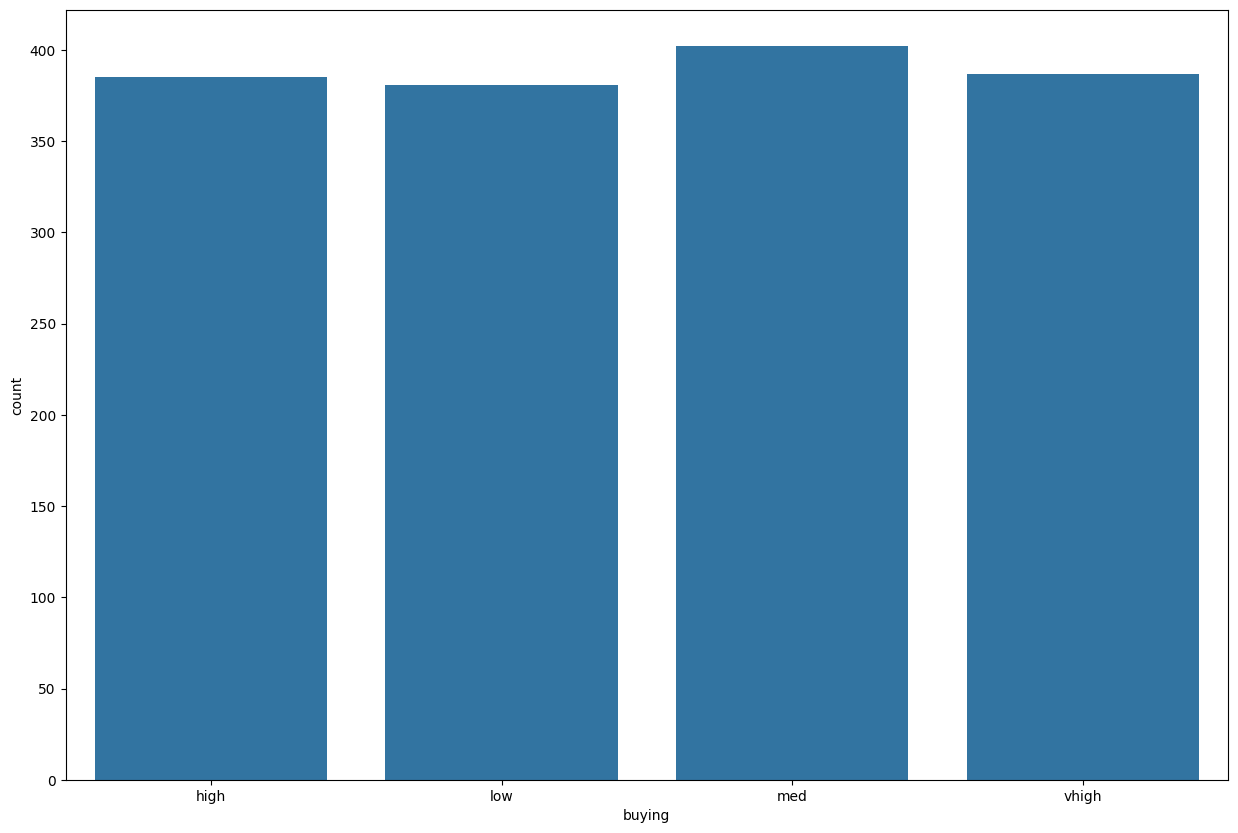

In [21]:
plt.figure(figsize=(15,10))
sns.countplot(train_data, x='buying')

<Axes: xlabel='buying', ylabel='count'>

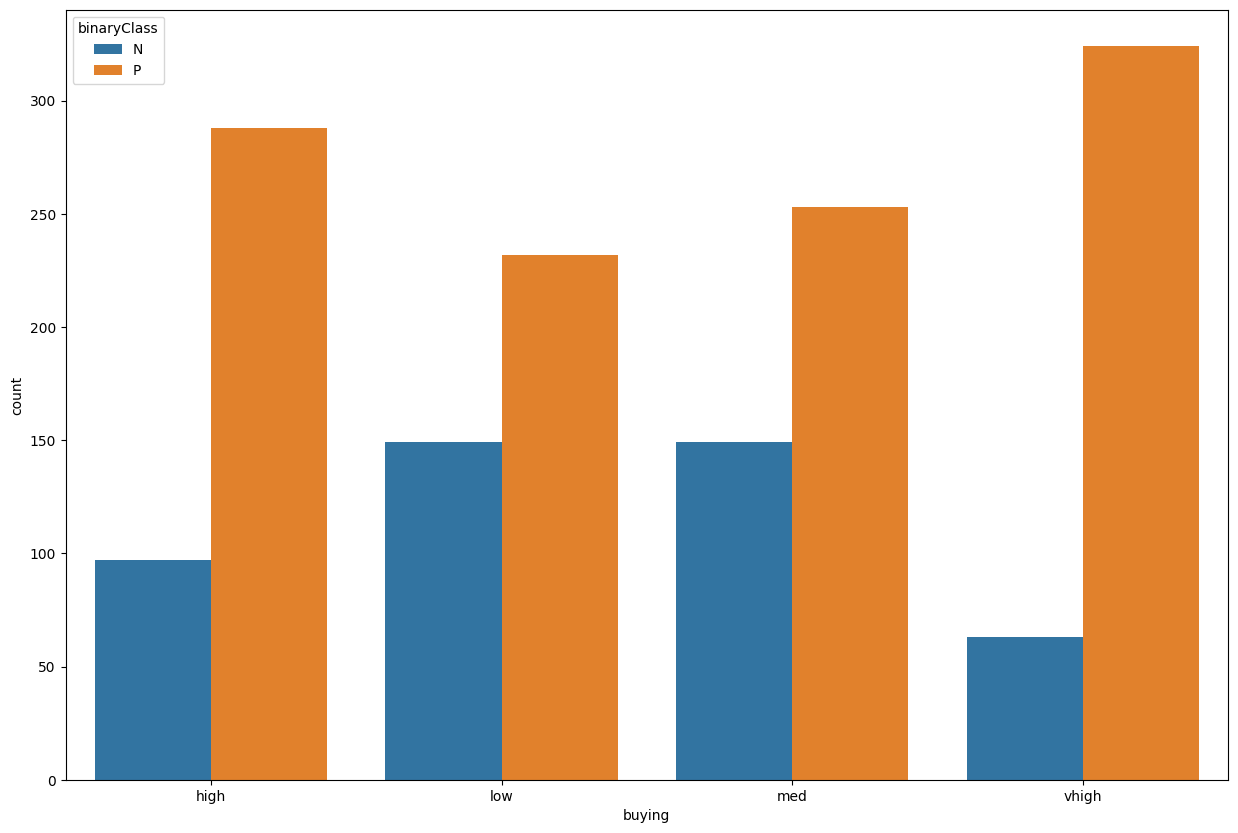

In [25]:
plt.figure(figsize=(15,10))
sns.countplot(train_data, x='buying',hue='binaryClass')

As you can see above, the majority class in the buying price is median(`med`).

In [26]:
train_data['maint'].value_counts()

maint
low      392
med      390
high     387
vhigh    386
Name: count, dtype: int64

<Axes: xlabel='maint', ylabel='count'>

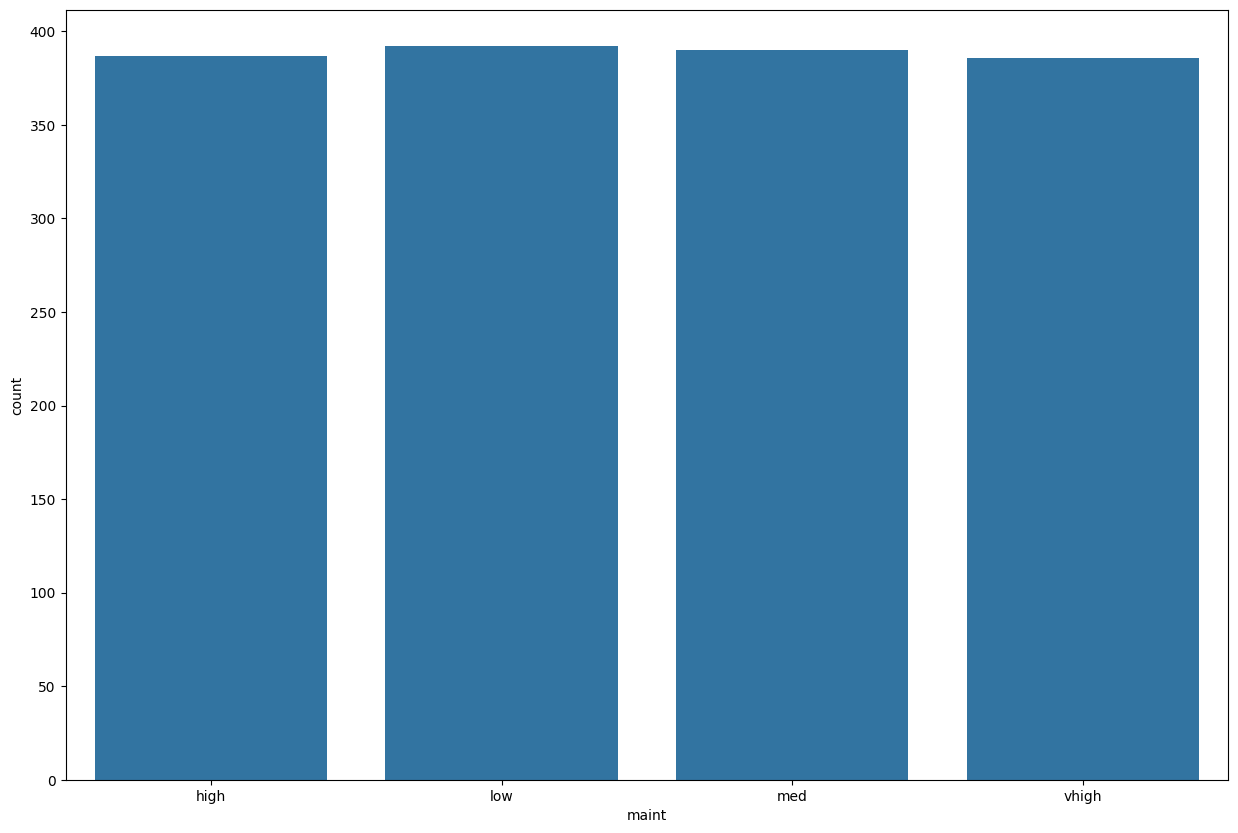

In [27]:
plt.figure(figsize=(15,10))
sns.countplot(train_data,x='maint')

<Axes: xlabel='maint', ylabel='count'>

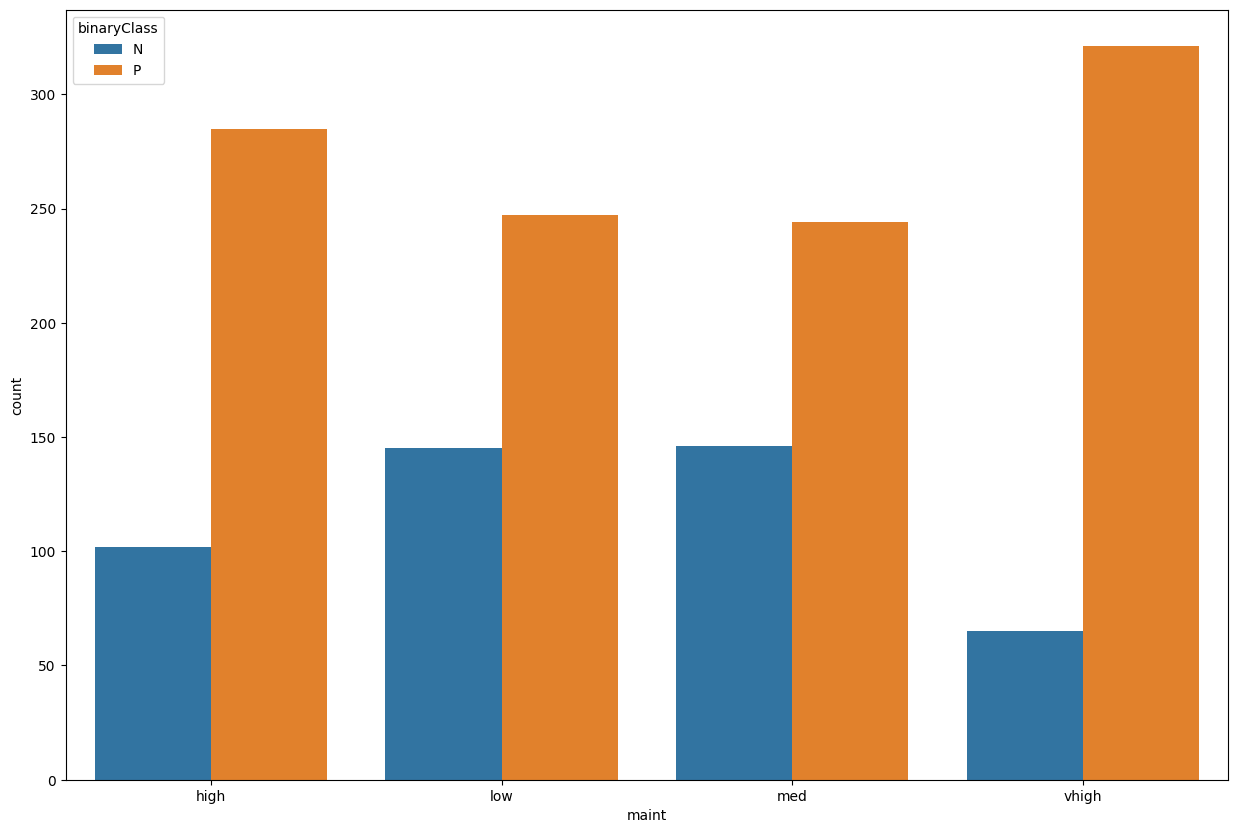

In [28]:
plt.figure(figsize=(15,10))
sns.countplot(train_data,x='maint', hue='binaryClass')

In [29]:
train_data['doors'].value_counts()

doors
2        393
4        393
5more    389
3        380
Name: count, dtype: int64

<Axes: xlabel='doors', ylabel='count'>

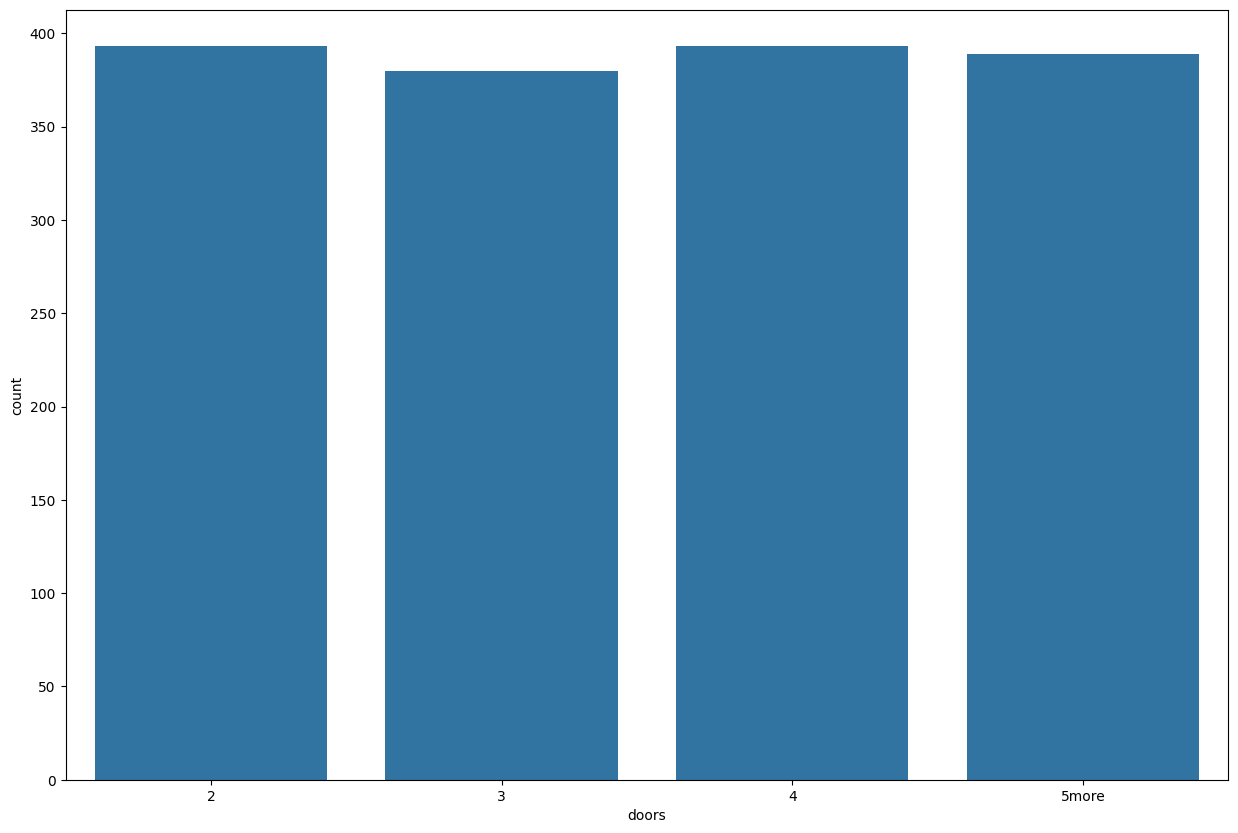

In [30]:
plt.figure(figsize=(15,10))
sns.countplot(train_data, x='doors')

<Axes: xlabel='doors', ylabel='count'>

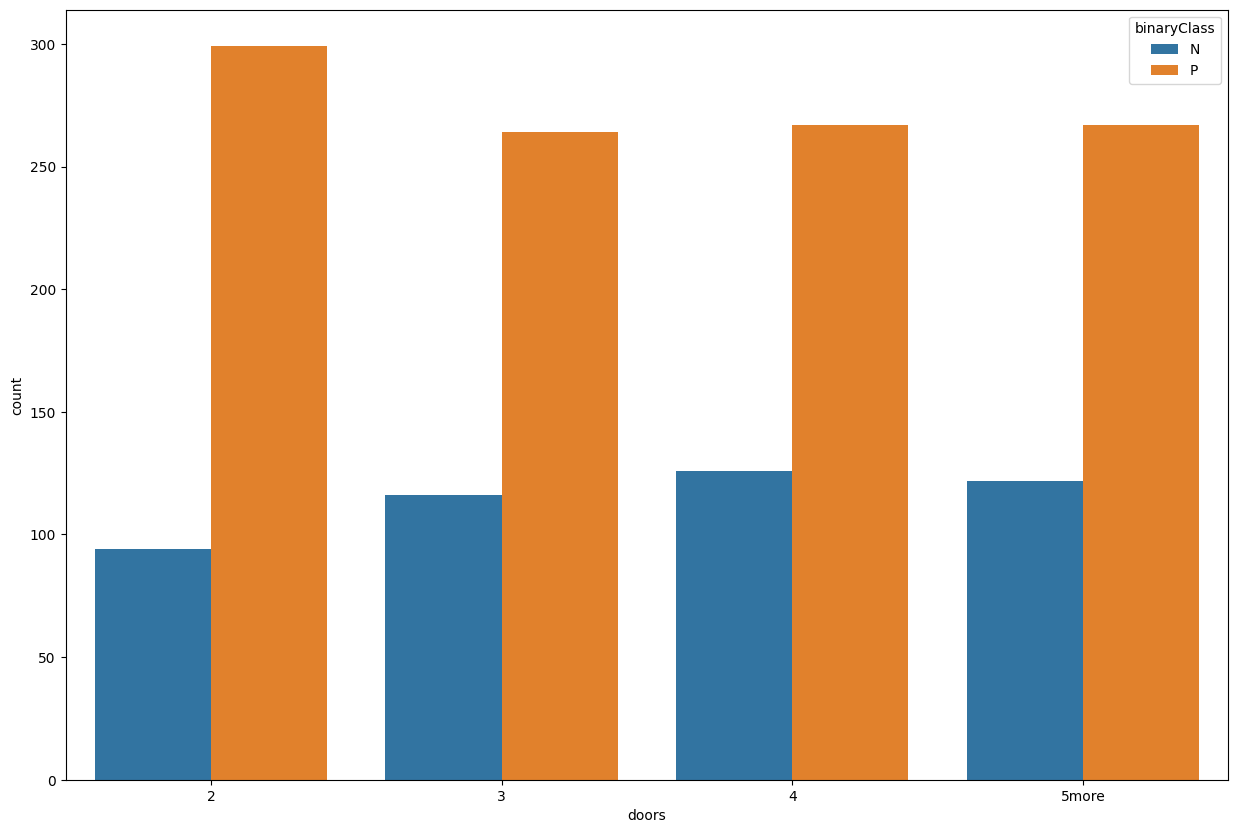

In [31]:
plt.figure(figsize=(15,10))
sns.countplot(train_data, x='doors',hue='binaryClass')

In [32]:
train_data['persons'].value_counts()

persons
2       521
more    521
4       513
Name: count, dtype: int64

<Axes: xlabel='persons', ylabel='count'>

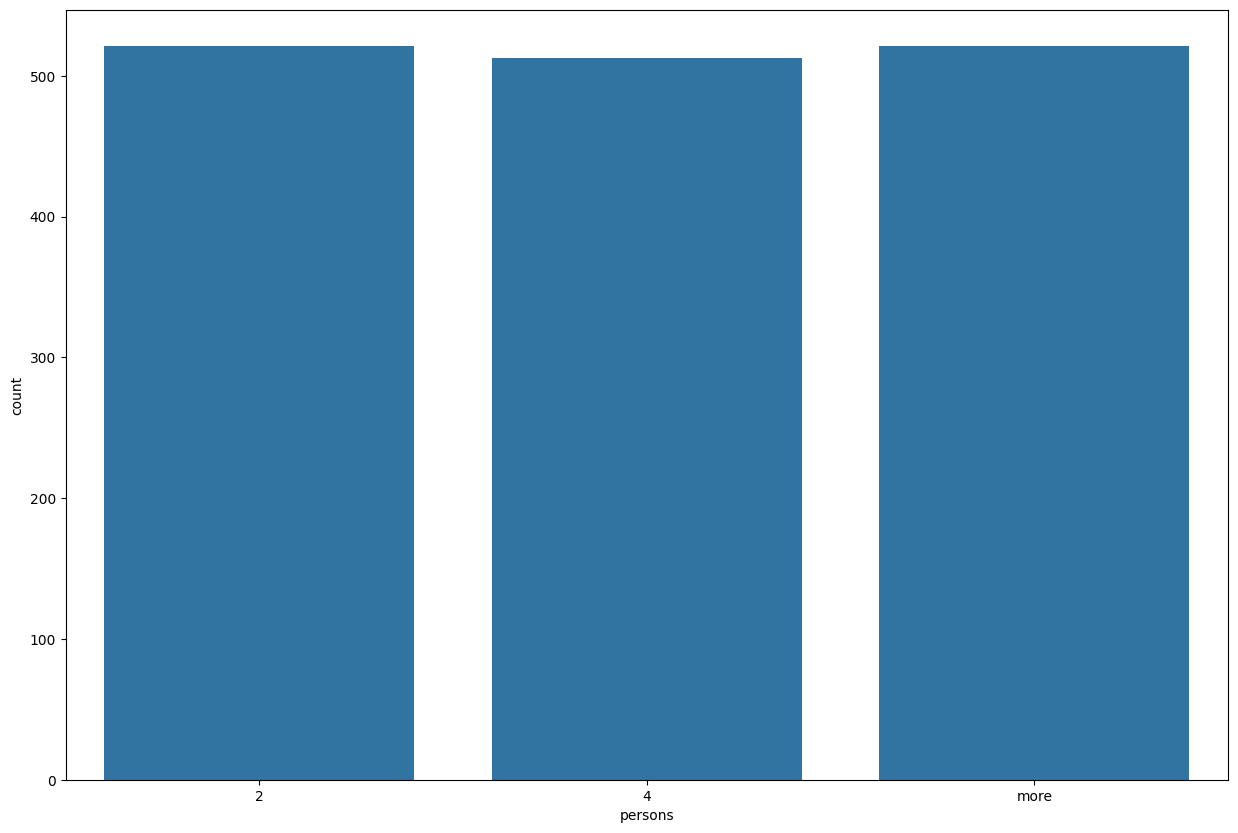

In [33]:
plt.figure(figsize=(15,10))
sns.countplot(train_data,x='persons')

<Axes: xlabel='persons', ylabel='count'>

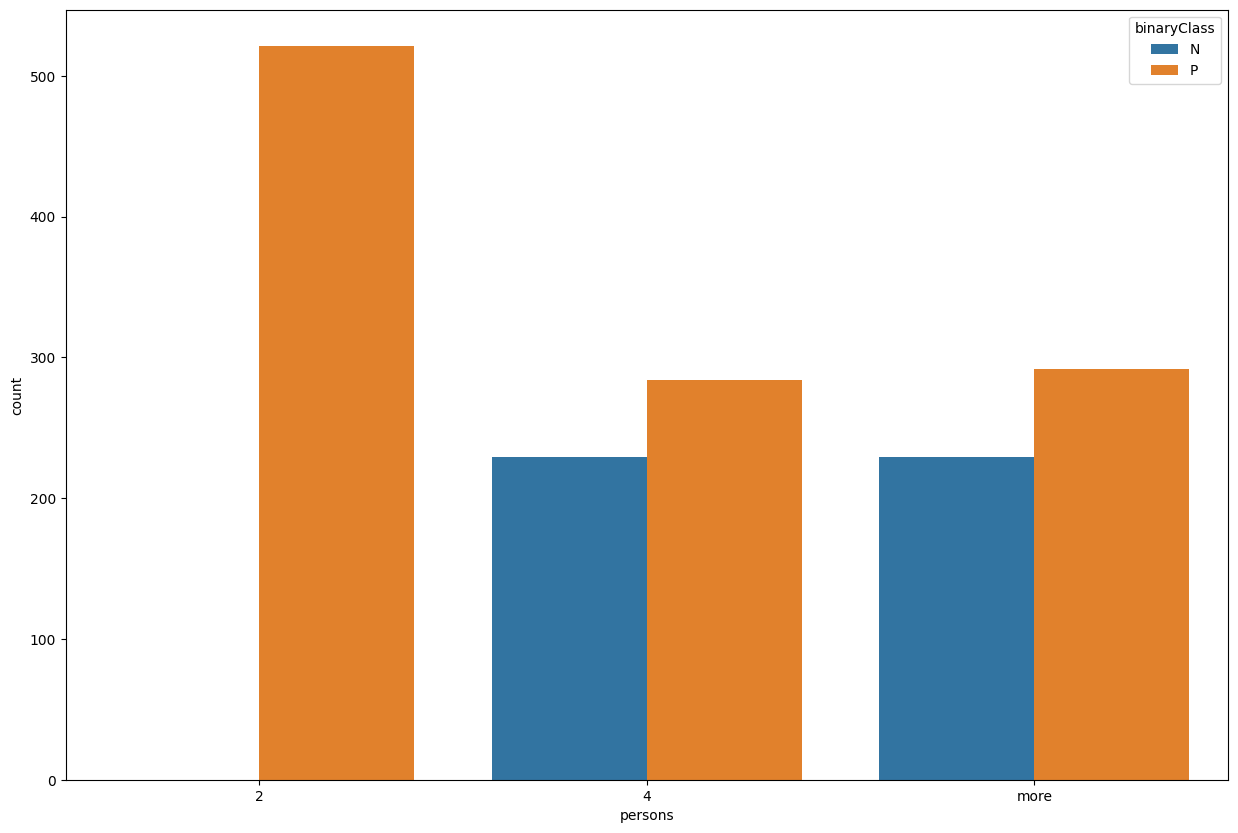

In [34]:
plt.figure(figsize=(15,10))
sns.countplot(train_data,x='persons', hue='binaryClass')

In [35]:
train_data['lug_boot'].value_counts()

lug_boot
med      522
small    517
big      516
Name: count, dtype: int64

<Axes: xlabel='lug_boot', ylabel='count'>

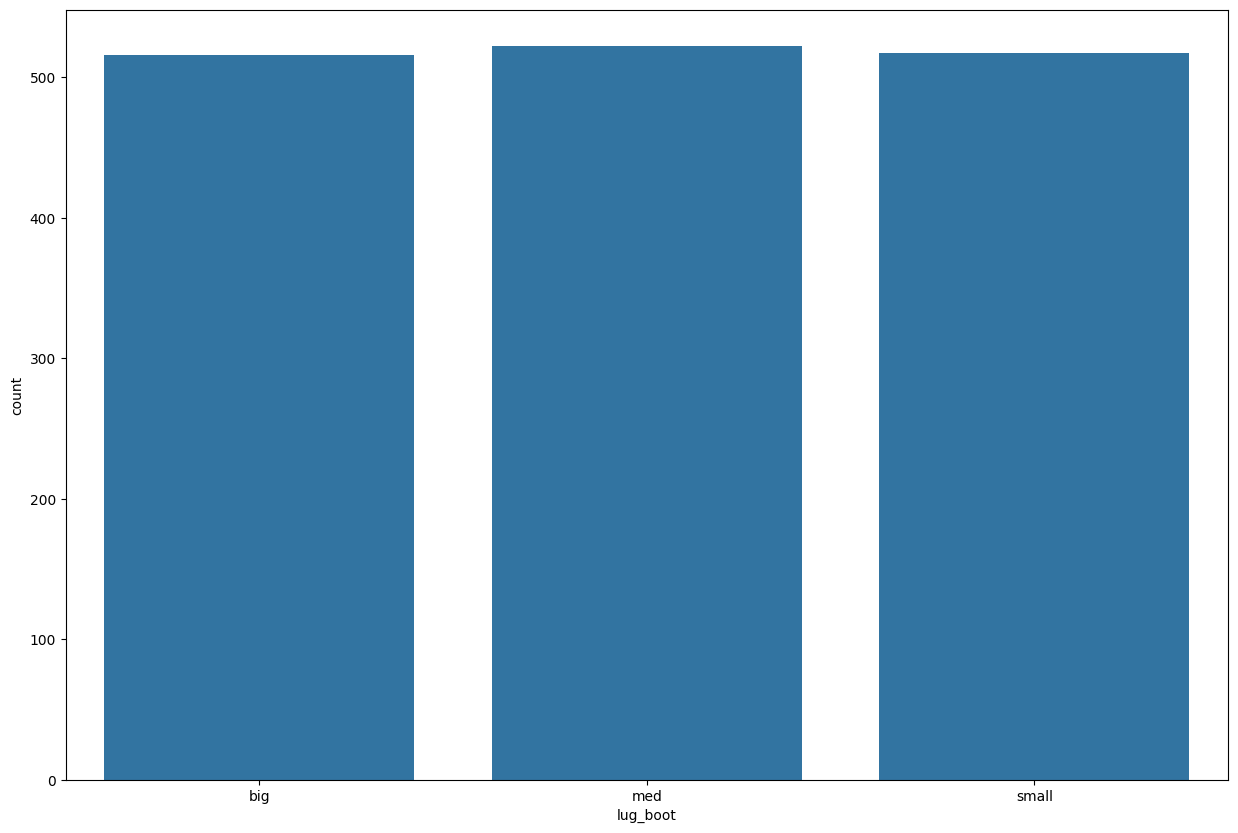

In [36]:
plt.figure(figsize=(15,10))
sns.countplot(train_data, x='lug_boot')

<Axes: xlabel='lug_boot', ylabel='count'>

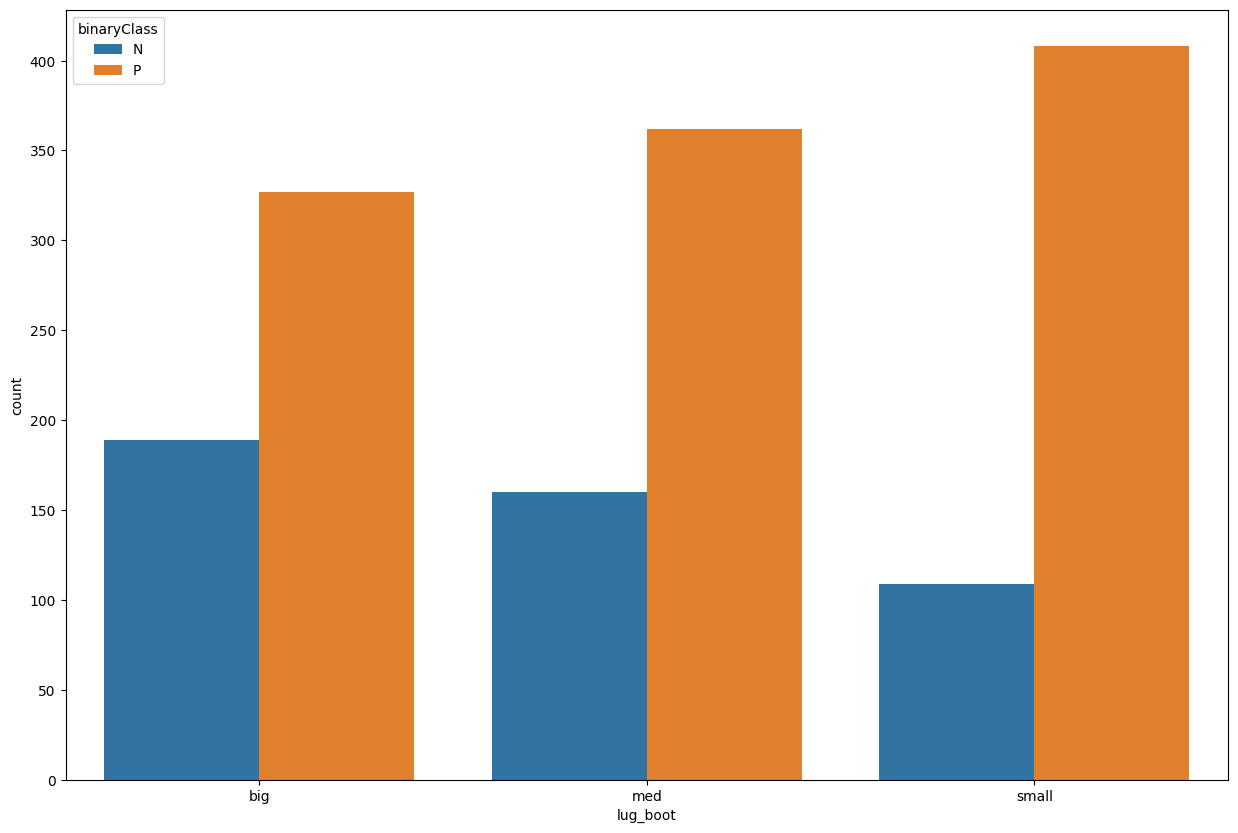

In [37]:
plt.figure(figsize=(15,10))
sns.countplot(train_data, x='lug_boot', hue='binaryClass')

In [38]:
train_data['safety'].value_counts()

safety
low     528
high    514
med     513
Name: count, dtype: int64

<Axes: xlabel='safety', ylabel='count'>

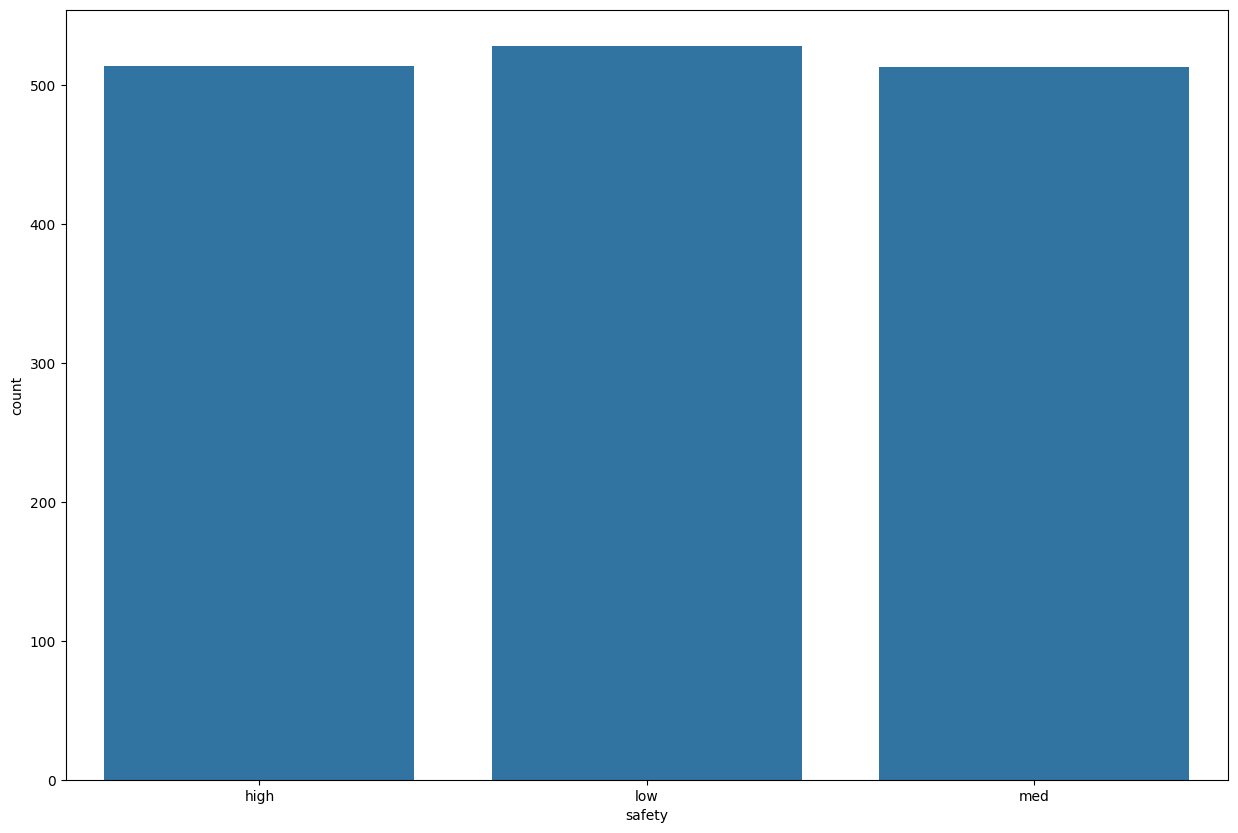

In [39]:
plt.figure(figsize=(15,10))
sns.countplot(train_data,x='safety')

<Axes: xlabel='safety', ylabel='count'>

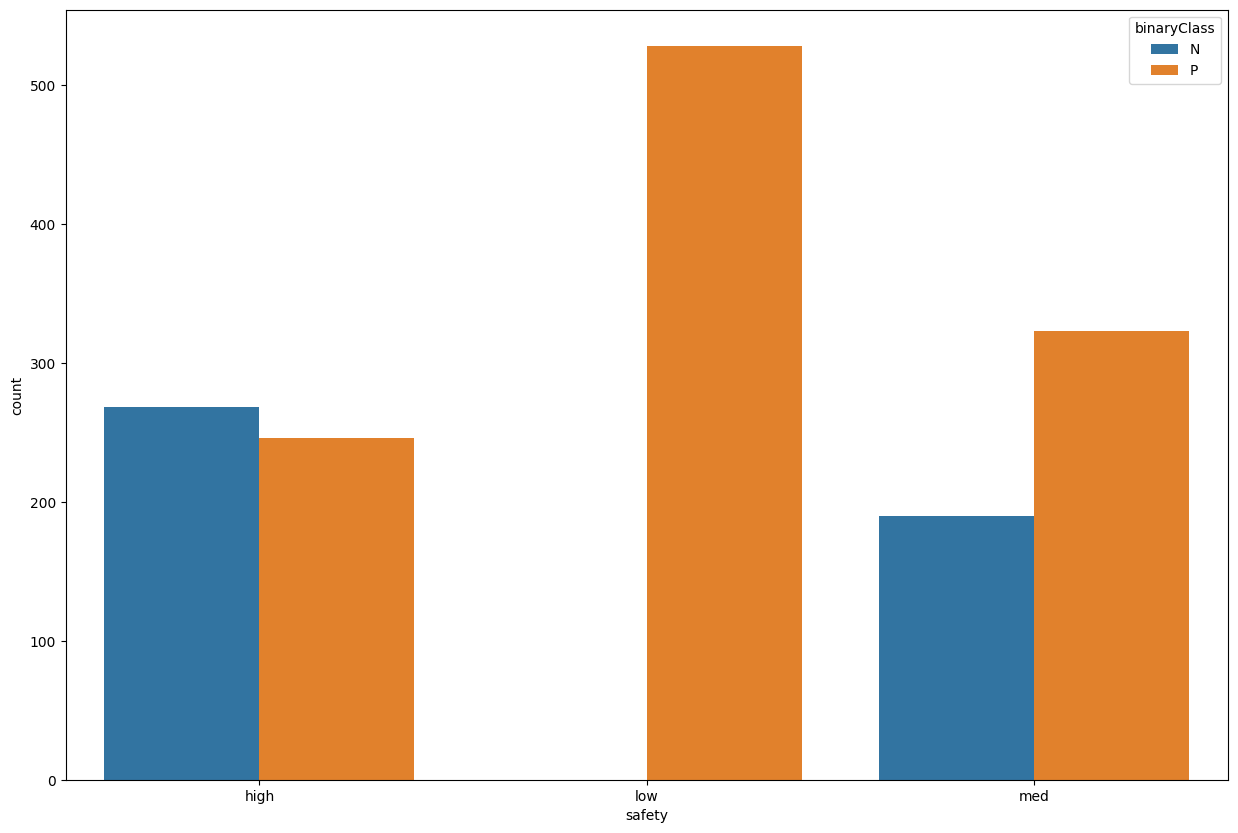

In [40]:
plt.figure(figsize=(15,10))
sns.countplot(train_data,x='safety', hue='binaryClass')

In [41]:
train_data['binaryClass'].value_counts()

binaryClass
P    1097
N     458
Name: count, dtype: int64

<Axes: xlabel='binaryClass', ylabel='count'>

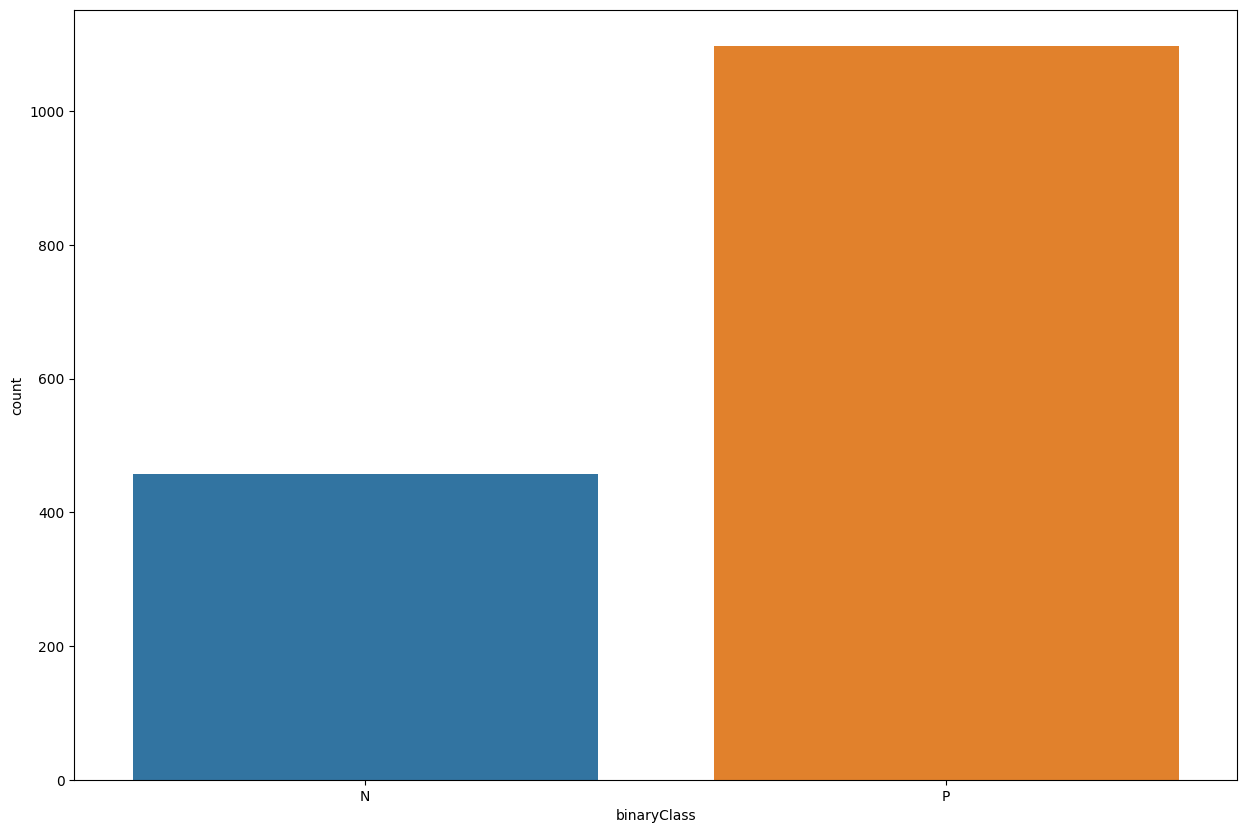

In [44]:
plt.figure(figsize=(15,10))
sns.countplot(train_data, x='binaryClass', hue='binaryClass')

As you can see, our data is completely skewed/imbalanced. The positive examples are 2x more than negative examples.

So we will remember during the model evaluation that accuracy is not the right metric in this case. Real world datasets comes with their unique blends, dataset can be imbalanced. Missing values can be present. We just have to find the effective way to deal with those issues. So again for evaluation, we will not rely on accuracy.

### Data Preprocessing

#### Handling Categorical Features
Decision trees don't care if the features are scaled or not, and they can handle the categorical features. There is a note that the sklearn tree implementation doesn't support categorical features, so I will go ahead and handle them.

Before handling categorical features, let's create a training input data and labels.

In [56]:
car_train=train_data.drop('binaryClass', axis=1)
car_labels=train_data[['binaryClass']]

In [57]:
type(car_labels)

pandas.core.frame.DataFrame

In [59]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline

pipe =Pipeline([
    ('ordEnco',OrdinalEncoder())
])

car_train_prepared=pipe.fit_transform(car_train)

In [60]:
car_train_prepared

array([[1., 3., 2., 1., 2., 0.],
       [2., 0., 2., 1., 2., 0.],
       [3., 2., 2., 1., 2., 0.],
       ...,
       [3., 2., 2., 0., 2., 2.],
       [0., 3., 1., 1., 0., 1.],
       [1., 3., 3., 0., 2., 0.]], shape=(1555, 6))

In [62]:
from sklearn.preprocessing import LabelEncoder

label_enc=LabelEncoder()

car_labels_prepared=label_enc.fit_transform(car_labels)

/workspaces/learn-ML/MLenv/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [63]:
car_labels_prepared

array([0, 0, 0, ..., 1, 1, 1], shape=(1555,))

### Training Decision Tree Classifier

In [65]:
from sklearn.tree import DecisionTreeClassifier

tree_clf=DecisionTreeClassifier()
tree_clf.fit(car_train_prepared,car_labels_prepared)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Evaluating Decision Trees

Let's build 3 functions to display accuracy, confusion matrix, and classification report. Classification report contains all useful metrics such as precision, recall, and f1 score.

In [91]:
from sklearn.metrics import accuracy_score

def accuracy(input_data,model,labels):
    preds=model.predict(input_data)
    acc=accuracy_score(labels,preds)
    return acc

In [93]:
from sklearn.metrics import confusion_matrix

def conf_matrix(input_data,model,labels):
    preds=model.predict(input_data)
    cm=confusion_matrix(labels,preds)
    return cm

In [94]:
from sklearn.metrics import classification_report

def class_report(input_data,model,labels):
    pred=model.predict(input_data)
    report=classification_report(labels,pred)
    return report

In [96]:
print(accuracy(car_train_prepared,tree_clf,car_labels_prepared))

1.0


In [97]:
print(conf_matrix(car_train_prepared,tree_clf,car_labels_prepared))

[[ 458    0]
 [   0 1097]]


In [76]:
print(class_report(car_train_prepared,tree_clf,car_labels_prepared))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       458
           1       1.00      1.00      1.00      1097

    accuracy                           1.00      1555
   macro avg       1.00      1.00      1.00      1555
weighted avg       1.00      1.00      1.00      1555



### Improving Decision Trees

In [78]:
tree_clf.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

One way to avoid overfitting is reduce number maximum depth of the tree, set by the hyperparameter `max_depth`. Similarly, we can attempt to reduce all hyperparameters with `max` term while also increasing the `min_` term parameters.

Also, I set the `class_weight` to `balanced` because our dataset is imbalanced. By setting it to balanced, the model will automatically adjust the class weight based on the number of available samples in all classes.

Let's use GridSearch to find best values of these hyperparameters. 

In [79]:
import warnings
warnings.filterwarnings('ignore')

In [80]:
from sklearn.model_selection import GridSearchCV

params_grid = {'max_leaf_nodes': list(range(0, 10)), 
               'min_samples_split': [0,1,2, 3, 4], 
               'min_samples_leaf': [0,1,2, 3, 4], 
               'max_depth':[0,1,2,3,4,5],
               'max_features':[0,1,2,3,4,5],
              'max_leaf_nodes':[0,1,2,3,4,5]}

grid_search=GridSearchCV(DecisionTreeClassifier(random_state=42, class_weight='balanced'),params_grid,verbose=1,cv=3, refit=True)
grid_search.fit(car_train_prepared,car_labels_prepared)

Fitting 3 folds for each of 5400 candidates, totalling 16200 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [0, 1, ...], 'max_features': [0, 1, ...], 'max_leaf_nodes': [0, 1, ...], 'min_samples_leaf': [0, 1, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [81]:
grid_search.best_params_

{'max_depth': 4,
 'max_features': 5,
 'max_leaf_nodes': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [83]:
tree_best=grid_search.best_estimator_

In [84]:
car_data.columns

Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety',
       'binaryClass'],
      dtype='object')

[Text(0.2857142857142857, 0.9, 'persons <= 0.5\ngini = 0.5\nsamples = 1555\nvalue = [777.5, 777.5]\nclass = N'),
 Text(0.14285714285714285, 0.7, 'gini = 0.0\nsamples = 521\nvalue = [0.0, 369.259]\nclass = P'),
 Text(0.21428571428571427, 0.8, 'True  '),
 Text(0.42857142857142855, 0.7, 'safety <= 0.5\ngini = 0.452\nsamples = 1034\nvalue = [777.5, 408.241]\nclass = N'),
 Text(0.3571428571428571, 0.8, '  False'),
 Text(0.2857142857142857, 0.5, 'gini = 0.189\nsamples = 344\nvalue = [454.956, 53.865]\nclass = N'),
 Text(0.5714285714285714, 0.5, 'safety <= 1.5\ngini = 0.499\nsamples = 690\nvalue = [322.544, 354.376]\nclass = P'),
 Text(0.42857142857142855, 0.3, 'gini = 0.0\nsamples = 351\nvalue = [0.0, 248.772]\nclass = P'),
 Text(0.7142857142857143, 0.3, 'lug_boot <= 1.5\ngini = 0.372\nsamples = 339\nvalue = [322.544, 105.604]\nclass = N'),
 Text(0.5714285714285714, 0.1, 'gini = 0.24\nsamples = 225\nvalue = [275.011, 44.651]\nclass = N'),
 Text(0.8571428571428571, 0.1, 'gini = 0.492\nsamples

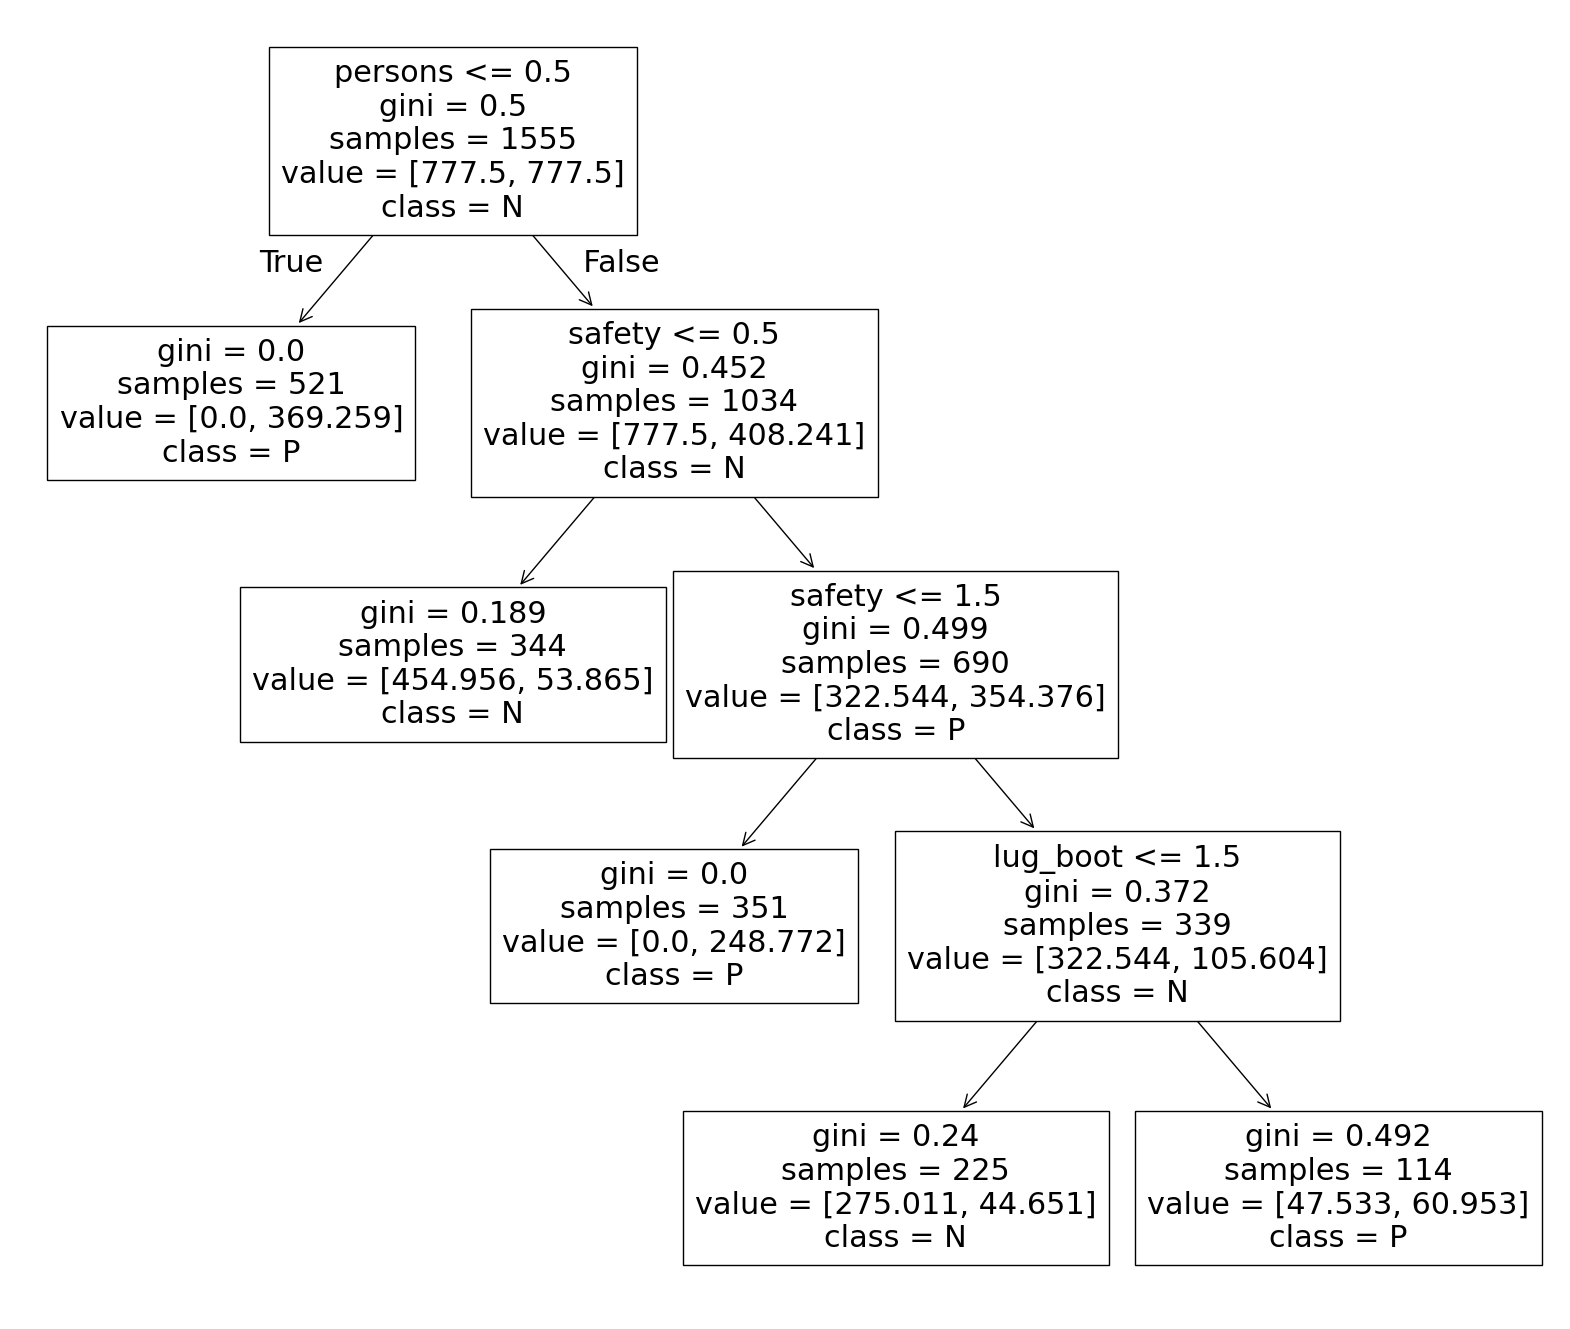

In [88]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,17))
plot_tree(tree_best,feature_names=car_data.columns, class_names=['N','P'])

In [95]:
print(accuracy(car_train_prepared,tree_best,car_labels_prepared))

0.8926045016077171


In [98]:
conf_matrix(car_train_prepared,tree_best,car_labels_prepared)

array([[430,  28],
       [139, 958]])

In confusion matrix, each row represent an actual class and each column represents predicted class.

So, from the results above:

* 430 negative examples(N) were correcty predicted as negatives(`true negatives`).
* 28 negatives examples(N) were incorrectly classified as positive examples when they are in fact negatives(`false positives`).
* 139 positive examples were incorrectly classified as negative(N) when in fact they are positives(P) (`false negatives`).
* 958 were correctly classified as positive examples(`true positives`).

In [100]:
print(class_report(car_train_prepared,tree_best,car_labels_prepared))

              precision    recall  f1-score   support

           0       0.76      0.94      0.84       458
           1       0.97      0.87      0.92      1097

    accuracy                           0.89      1555
   macro avg       0.86      0.91      0.88      1555
weighted avg       0.91      0.89      0.90      1555



Wow, this is much better. By only setting the class weight to `balanced` and finding the best values of the hyperparameters, we were able to improve our model.

If you remember, the negative class has fewer examples than the positive classes. You can see them in `support` in classification report. But our model is able to identify them correctly at 76%, and also is able to identify the positive examples at 97% without overfitting. That is precision.

A few notes about Precison/Recall/F1 score:

* Precision is the model accuracy on predicting positive examples correctly.
* Recall is the ratio of the positive examples that are correctly identified by the model.
* F1 score is the harmonic mean of precision and recall.

The higher the precision and recall are, the higher the F1 score. But there is a tradeoff between them. Increasing precision will reduce recall, and vice versa. So it's fair to say that it depends on the problem you're trying to solve and the metrics you want to optimize for.

### Evaluating the model on the test set

It is only after we have improved the model that we can feed it to the test set. If we try to show the test set to the model while we are still training, we may cause a potential leak thus producing misleading predictions.

Also, we will apply the same processing functions that we applied to the training set.

In [102]:
car_test=test_data.drop('binaryClass',axis=1)
car_test_labels=test_data['binaryClass']

In [ ]:
# Handling the categorical features with the pipeline that we defined early
# We don't fit on the test data. Only transform
car_test_prepared=pipe.transform(car_test)

In [106]:
car_test_labels_prepared=label_enc.transform(car_test_labels)

In [107]:
accuracy(car_test_prepared,tree_best,car_test_labels_prepared)

0.8554913294797688

In [108]:
conf_matrix(car_test_prepared,tree_best,car_test_labels_prepared)

array([[53,  7],
       [18, 95]])

In [110]:
print(class_report(car_test_prepared,tree_best,car_test_labels_prepared))

              precision    recall  f1-score   support

           0       0.75      0.88      0.81        60
           1       0.93      0.84      0.88       113

    accuracy                           0.86       173
   macro avg       0.84      0.86      0.85       173
weighted avg       0.87      0.86      0.86       173

